# Machine Learning Assignment: Polynomial Regression

This notebook develops polynomial regression models for VAR1 and VAR2.

The workflow includes:

1. Dataset inspection and exploratory data analysis
2. Linear regression baselines
3. Polynomial degree selection using 5-fold cross-validation
4. Exhaustive feature-subset and degree search
5. Stability analysis around the selected degree
6. Regularized polynomial regression experiments
7. Final model selection
8. Training diagnostics and residual analysis
9. Test-set prediction and submission file validation

The final submission models are selected using 5-fold cross-validation
from both unregularized and regularized polynomial regression experiments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

In [2]:
# Loading data
train_var1 = pd.read_csv("Dataset/IMT2023555_train_var1.csv")
test_var1 = pd.read_csv("Dataset/IMT2023555_test_var1.csv")

train_var2 = pd.read_csv("Dataset/IMT2023555_train_var2.csv")
test_var2 = pd.read_csv("Dataset/IMT2023555_test_var2.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Dataset Inspection and Validation

In [3]:
#Initial Dataset Inspection
datasets = {
    "VAR1 Train": train_var1,
    "VAR1 Test": test_var1,
    "VAR2 Train": train_var2,
    "VAR2 Test": test_var2
}

for name, df in datasets.items():
    print(name)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())
    print()

VAR1 Train
Shape: (1000, 7)
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']

First 5 rows:


,x1,x2,x3,x4,x5,x6,y
0,-0.129656,0.100041,-0.683686,-1.000000,1.000000,1.000000,6.944284
1,0.670291,-1.000000,-0.594414,-0.080961,-1.000000,-1.000000,4.504368
2,-0.858342,0.538874,-1.000000,0.824375,0.149936,-0.403362,-0.271141
3,0.231969,0.681520,1.000000,1.000000,0.749791,-0.063300,-3.589001
4,-0.978277,-0.914562,0.608867,-0.672189,0.991487,0.522336,1.285541



VAR1 Test
Shape: (1000, 6)
Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

First 5 rows:


,x1,x2,x3,x4,x5,x6
0,0.918153,1.000000,1.000000,1.000000,0.879090,-1.000000
1,-0.355651,-1.000000,-0.816774,-0.600370,0.645933,-0.518338
2,-1.000000,0.573736,-0.145786,0.286548,-1.000000,-0.235250
3,0.222118,0.925009,1.000000,1.000000,0.594403,-1.000000
4,0.387160,0.684161,0.877487,0.265945,1.000000,-1.000000



VAR2 Train
Shape: (1000, 4)
Columns: ['x1', 'x2', 'x3', 'y']

First 5 rows:


,x1,x2,x3,y
0,-0.133516,-0.082212,-0.523733,0.620220
1,-1.000000,1.000000,0.930699,10.306113
2,1.000000,-1.000000,-0.286713,-9.952886
3,0.008912,0.147405,-0.143078,-0.164930
4,0.117216,1.000000,-1.000000,4.391439



VAR2 Test
Shape: (1000, 3)
Columns: ['x1', 'x2', 'x3']

First 5 rows:


,x1,x2,x3
0,0.140341,0.312902,0.968638
1,1.000000,-0.728585,-1.000000
2,0.781299,-0.145999,0.655323
3,0.261268,-1.000000,-0.186221
4,0.190208,-0.066386,1.000000


In [4]:
#Data Types and Structural Validation
for name, df in datasets.items():
    print(name)
    
    print("\nData types:")
    print(df.dtypes)
    
    print("\nNumber of rows:", df.shape[0])
    print("Number of columns:", df.shape[1])
    print("Shape:", df.shape)
    print()

VAR1 Train

Data types:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
y     float64
dtype: object

Number of rows: 1000
Number of columns: 7
Shape: (1000, 7)

VAR1 Test

Data types:
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
dtype: object

Number of rows: 1000
Number of columns: 6
Shape: (1000, 6)

VAR2 Train

Data types:
x1    float64
x2    float64
x3    float64
y     float64
dtype: object

Number of rows: 1000
Number of columns: 4
Shape: (1000, 4)

VAR2 Test

Data types:
x1    float64
x2    float64
x3    float64
dtype: object

Number of rows: 1000
Number of columns: 3
Shape: (1000, 3)



In [5]:
#Missing Values and Duplicate Checks

for name, df in datasets.items():
    print(name)
    
    # Missing values
    print("\nMissing values:")
    print(df.isnull().sum())
    
    # Total missing values
    print("Total missing values:", df.isnull().sum().sum())
    
    # Duplicate rows
    print("Duplicate rows:", df.duplicated().sum())
    print()

VAR1 Train

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
y     0
dtype: int64
Total missing values: 0
Duplicate rows: 0

VAR1 Test

Missing values:
x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64
Total missing values: 0
Duplicate rows: 6

VAR2 Train

Missing values:
x1    0
x2    0
x3    0
y     0
dtype: int64
Total missing values: 0
Duplicate rows: 0

VAR2 Test

Missing values:
x1    0
x2    0
x3    0
dtype: int64
Total missing values: 0
Duplicate rows: 7



In [6]:
#Descriptive Statistics

print("VAR1 TRAIN")
display(train_var1.describe())

print("\nVAR1 TEST")
display(test_var1.describe())

print("\nVAR2 TRAIN")
display(train_var2.describe())

print("\nVAR2 TEST")
display(test_var2.describe())

VAR1 TRAIN


,x1,x2,x3,x4,x5,x6,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.020107,-0.031860,-0.039200,0.011616,-0.025487,-0.020440,0.812705
std,0.709136,0.715385,0.715766,0.711716,0.720960,0.712473,3.208412
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-9.923569
25%,-0.631555,-0.725827,-0.717141,-0.646359,-0.756234,-0.694169,-1.113509
50%,0.020970,-0.056768,-0.024403,0.023649,-0.025856,-0.037408,0.713120
75%,0.708374,0.633124,0.606706,0.676418,0.623089,0.634202,2.873062
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.073484



VAR1 TEST


,x1,x2,x3,x4,x5,x6
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.016050,0.009140,0.018226,-0.027523,-0.003454,0.002371
std,0.838001,0.828991,0.817927,0.810866,0.817327,0.811412
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-0.975646,-1.000000,-1.000000,-0.958856
50%,0.024795,0.024635,0.050096,-0.053143,-0.009039,-0.030076
75%,1.000000,1.000000,1.000000,0.955874,1.000000,0.978557
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



VAR2 TRAIN


,x1,x2,x3,y
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.026917,-0.004836,0.004569,2.154694
std,0.686322,0.672472,0.691972,6.629498
min,-1.000000,-1.000000,-1.000000,-29.810902
25%,-0.561692,-0.568779,-0.604764,-0.857991
50%,0.041290,-0.011260,0.000185,1.181507
75%,0.665774,0.549675,0.629275,4.879908
max,1.000000,1.000000,1.000000,40.027946



VAR2 TEST


,x1,x2,x3
count,1000.000000,1000.000000,1000.000000
mean,-0.000604,-0.031637,0.030185
std,0.652049,0.659967,0.663108
min,-1.000000,-1.000000,-1.000000
25%,-0.558986,-0.623488,-0.505298
50%,0.017012,-0.019749,0.014709
75%,0.511147,0.500881,0.602221
max,1.000000,1.000000,1.000000


## 3. Exploratory Data Analysis

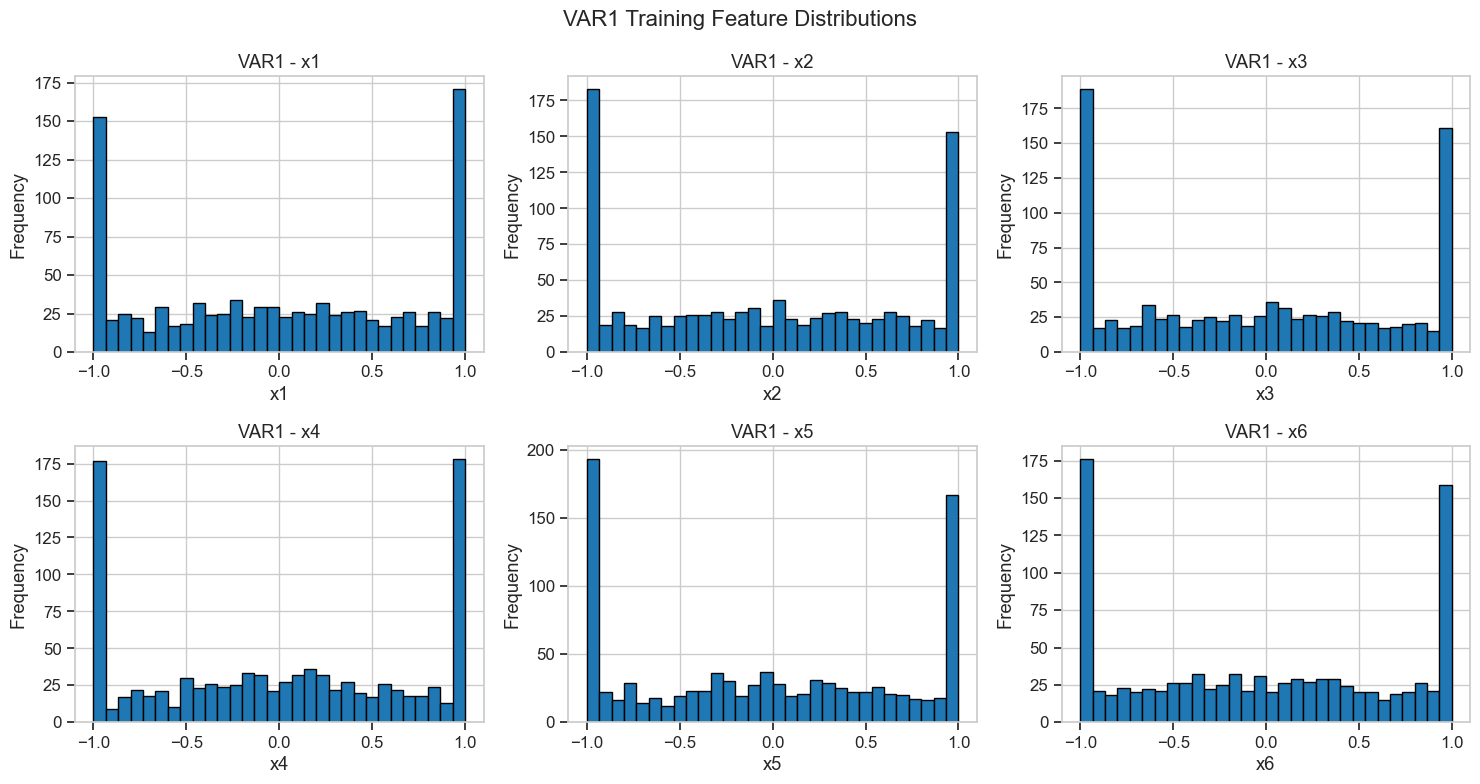

In [7]:
#VAR1 Feature Distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate([f"x{i}" for i in range(1, 7)]):
    ax = axes[i // 3, i % 3]
    
    ax.hist(train_var1[feature], bins=30, edgecolor="black")
    ax.set_title(f"VAR1 - {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.suptitle("VAR1 Training Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

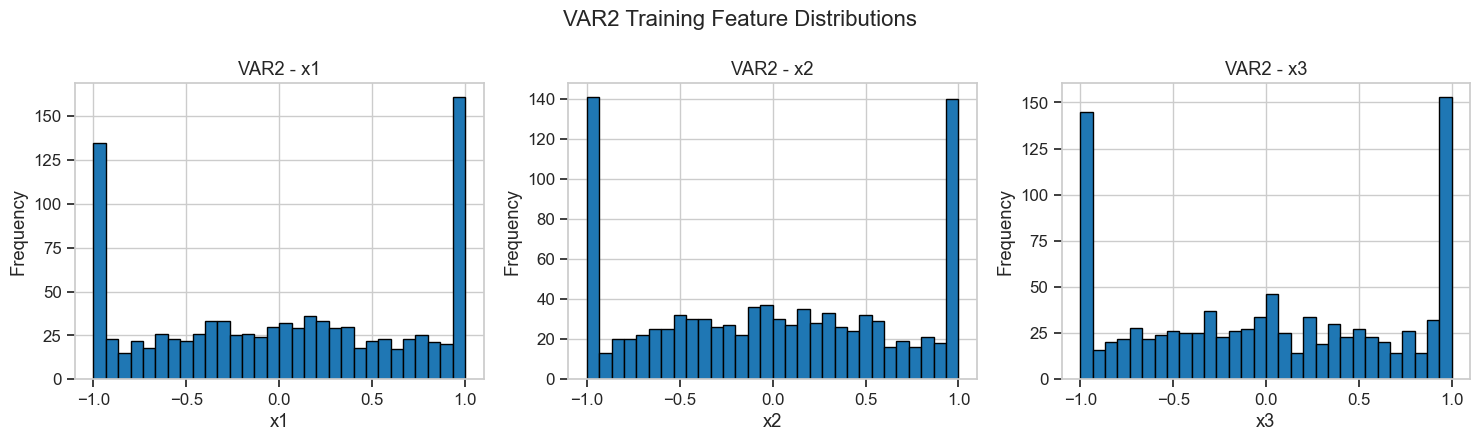

In [8]:
#VAR2 Feature Distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, feature in enumerate(["x1", "x2", "x3"]):
    ax = axes[i]
    
    ax.hist(train_var2[feature], bins=30, edgecolor="black")
    ax.set_title(f"VAR2 - {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.suptitle("VAR2 Training Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

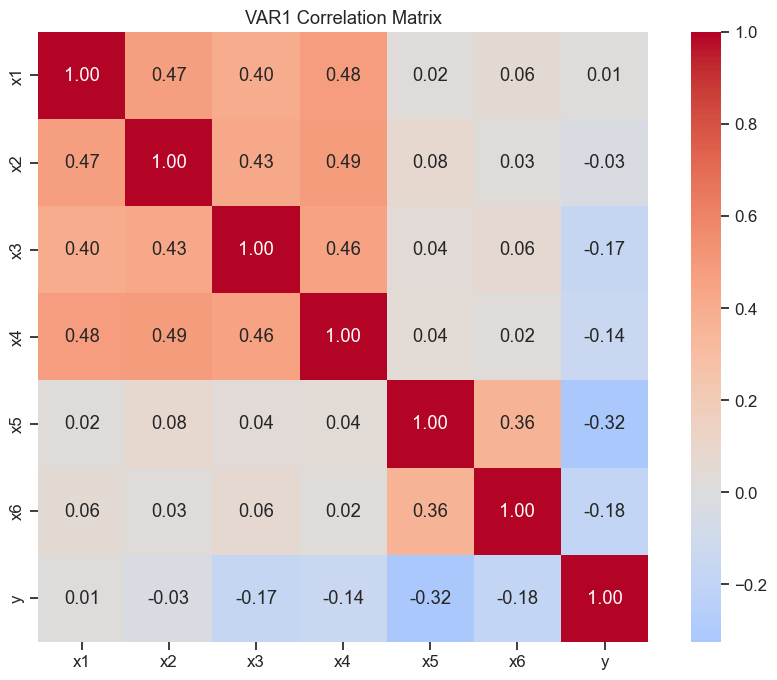

In [9]:
#VAR1 Correlation Analysis

corr_var1 = train_var1.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_var1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("VAR1 Correlation Matrix")
plt.tight_layout()
plt.show()

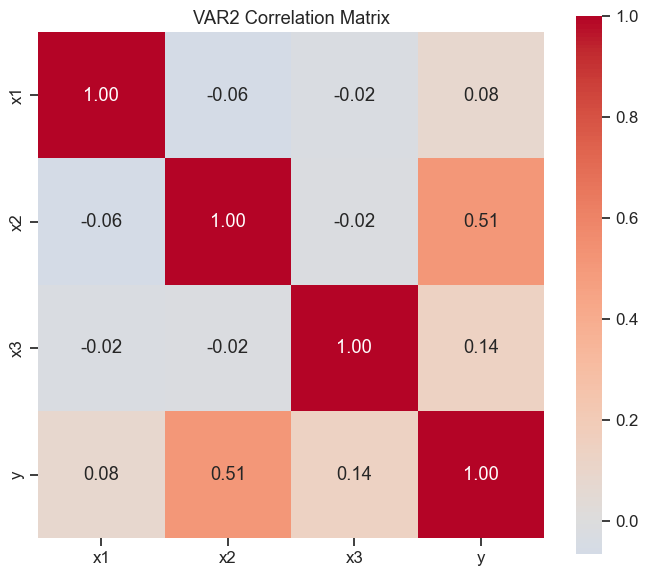

In [10]:
#VAR2 Correlation Analysis

corr_var2 = train_var2.corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_var2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("VAR2 Correlation Matrix")
plt.tight_layout()
plt.show()

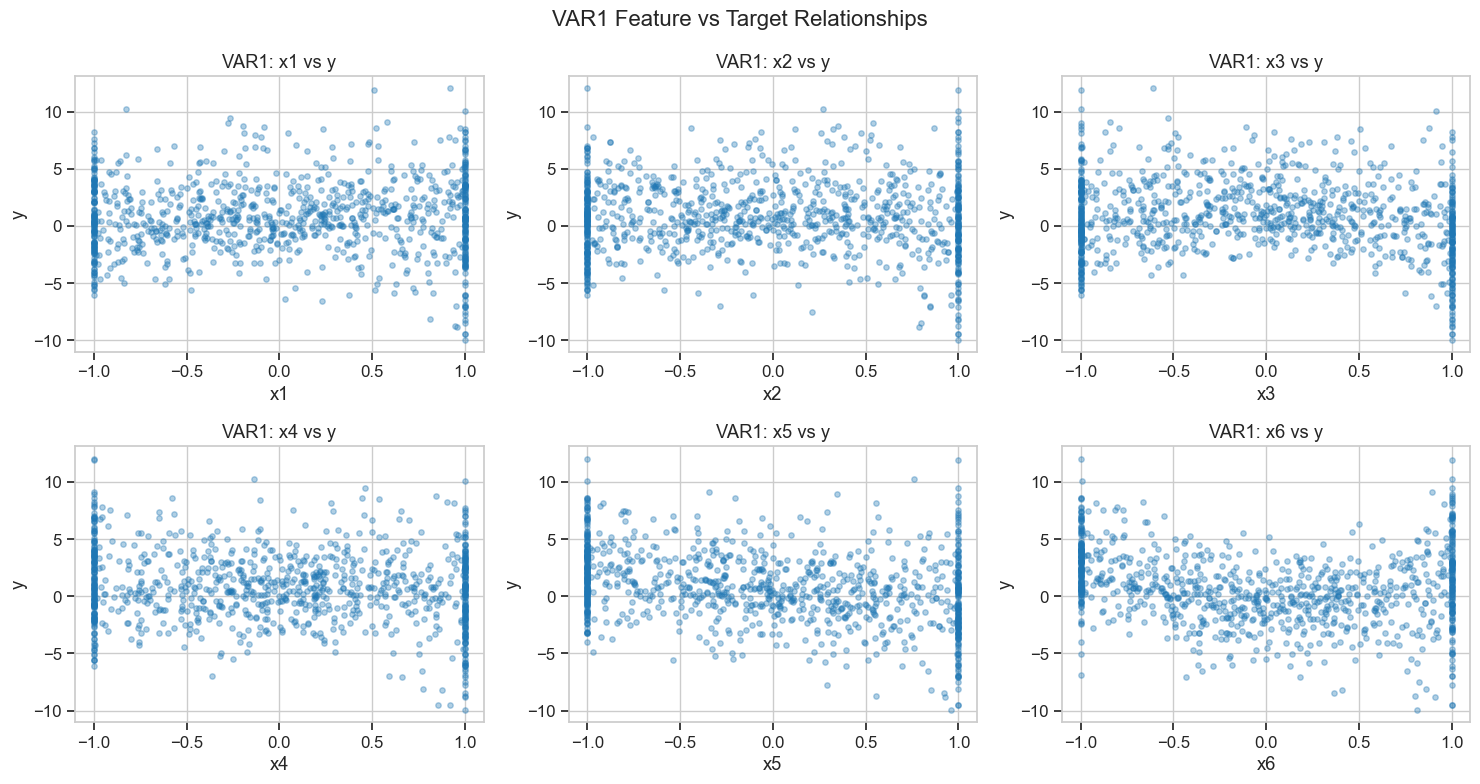

In [11]:
#VAR1 Feature vs Target Relationships

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features_v1 = ["x1", "x2", "x3", "x4", "x5", "x6"]

for i, feature in enumerate(features_v1):
    ax = axes[i // 3, i % 3]
    
    ax.scatter(
        train_var1[feature],
        train_var1["y"],
        alpha=0.35,
        s=15
    )
    
    ax.set_title(f"VAR1: {feature} vs y")
    ax.set_xlabel(feature)
    ax.set_ylabel("y")

plt.suptitle("VAR1 Feature vs Target Relationships", fontsize=16)
plt.tight_layout()
plt.show()

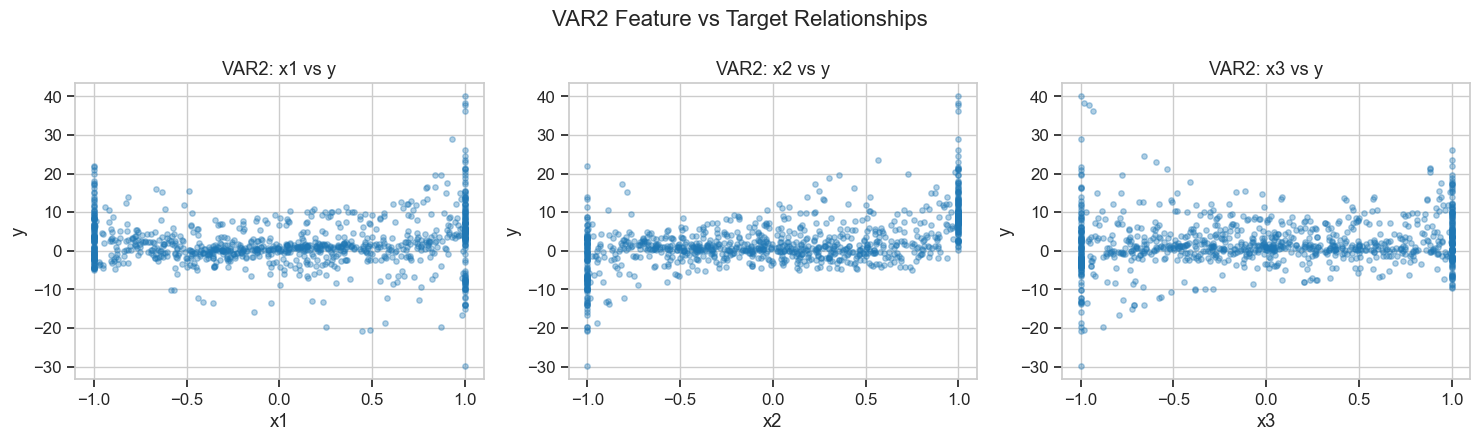

In [12]:
#VAR2 Feature vs Target Relationships

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

features_v2 = ["x1", "x2", "x3"]

for i, feature in enumerate(features_v2):
    ax = axes[i]
    
    ax.scatter(
        train_var2[feature],
        train_var2["y"],
        alpha=0.35,
        s=15
    )
    
    ax.set_title(f"VAR2: {feature} vs y")
    ax.set_xlabel(feature)
    ax.set_ylabel("y")

plt.suptitle("VAR2 Feature vs Target Relationships", fontsize=16)
plt.tight_layout()
plt.show()

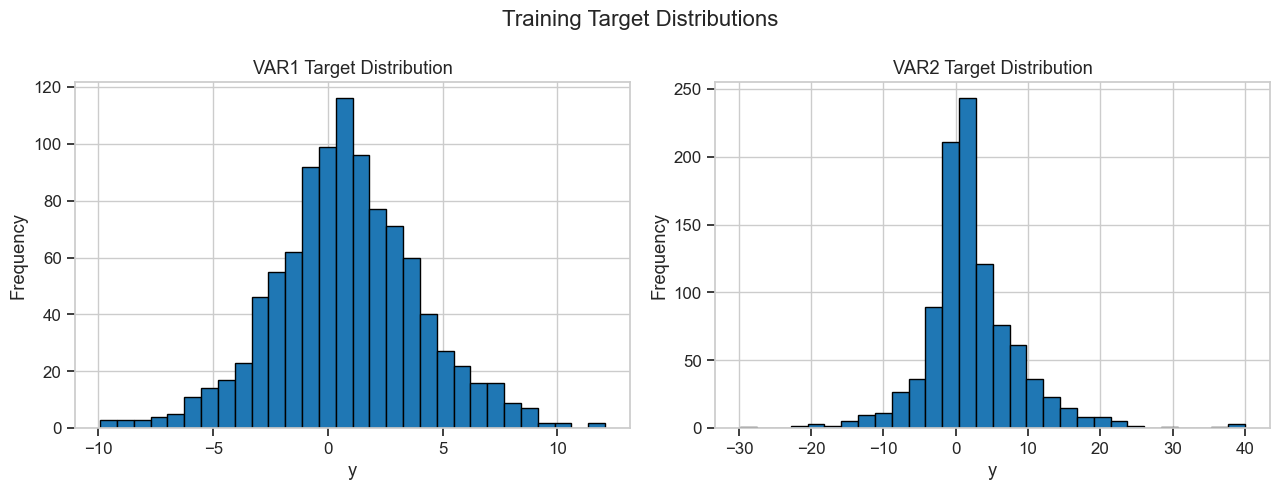

In [13]:
#Target Distributions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VAR1 target
axes[0].hist(
    train_var1["y"],
    bins=30,
    edgecolor="black"
)
axes[0].set_title("VAR1 Target Distribution")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Frequency")

# VAR2 target
axes[1].hist(
    train_var2["y"],
    bins=30,
    edgecolor="black"
)
axes[1].set_title("VAR2 Target Distribution")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Frequency")

plt.suptitle("Training Target Distributions", fontsize=16)
plt.tight_layout()
plt.show()

## 4. Feature and Target Preparation

In [14]:
#Separate Features and Target

# VAR1
X_v1 = train_var1.drop(columns=["y"])
y_v1 = train_var1["y"]

# VAR2
X_v2 = train_var2.drop(columns=["y"])
y_v2 = train_var2["y"]

print("VAR1")
print("X shape:", X_v1.shape)
print("y shape:", y_v1.shape)

print("\nVAR2")
print("X shape:", X_v2.shape)
print("y shape:", y_v2.shape)

VAR1
X shape: (1000, 6)
y shape: (1000,)

VAR2
X shape: (1000, 3)
y shape: (1000,)


## 5. Baseline Linear Regression

In [15]:
#Baseline Linear Regression with 5-Fold Cross-Validation

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Linear regression model
linear_model = LinearRegression()

# Evaluate VAR1
cv_v1 = cross_validate(
    linear_model,
    X_v1,
    y_v1,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Evaluate VAR2
cv_v2 = cross_validate(
    linear_model,
    X_v2,
    y_v2,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Convert negative MSE to normal positive MSE
v1_train_mse = -cv_v1["train_mse"].mean()
v1_val_mse = -cv_v1["test_mse"].mean()
v1_train_r2 = cv_v1["train_r2"].mean()
v1_val_r2 = cv_v1["test_r2"].mean()

v2_train_mse = -cv_v2["train_mse"].mean()
v2_val_mse = -cv_v2["test_mse"].mean()
v2_train_r2 = cv_v2["train_r2"].mean()
v2_val_r2 = cv_v2["test_r2"].mean()

print("VAR1 - Linear Regression Baseline")
print(f"Train MSE: {v1_train_mse:.6f}")
print(f"Validation MSE: {v1_val_mse:.6f}")
print(f"Train R²: {v1_train_r2:.6f}")
print(f"Validation R²: {v1_val_r2:.6f}\n")


print("\nVAR2 - Linear Regression Baseline")
print(f"Train MSE: {v2_train_mse:.6f}")
print(f"Validation MSE: {v2_val_mse:.6f}")
print(f"Train R²: {v2_train_r2:.6f}")
print(f"Validation R²: {v2_val_r2:.6f}")

VAR1 - Linear Regression Baseline
Train MSE: 8.663552
Validation MSE: 8.846755
Train R²: 0.157281
Validation R²: 0.135799


VAR2 - Linear Regression Baseline
Train MSE: 30.826585
Validation MSE: 31.298461
Train R²: 0.297707
Validation R²: 0.284147


## 6. Polynomial Regression Setup

In [16]:
#Degree-2 Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# Degree-2 polynomial regression pipeline
poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Evaluate VAR1
cv_poly2_v1 = cross_validate(
    poly2_model,
    X_v1,
    y_v1,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Evaluate VAR2
cv_poly2_v2 = cross_validate(
    poly2_model,
    X_v2,
    y_v2,
    cv=kf,
    scoring={
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True
)

# Convert negative MSE to positive MSE
poly2_v1_train_mse = -cv_poly2_v1["train_mse"].mean()
poly2_v1_val_mse = -cv_poly2_v1["test_mse"].mean()
poly2_v1_train_r2 = cv_poly2_v1["train_r2"].mean()
poly2_v1_val_r2 = cv_poly2_v1["test_r2"].mean()

poly2_v2_train_mse = -cv_poly2_v2["train_mse"].mean()
poly2_v2_val_mse = -cv_poly2_v2["test_mse"].mean()
poly2_v2_train_r2 = cv_poly2_v2["train_r2"].mean()
poly2_v2_val_r2 = cv_poly2_v2["test_r2"].mean()

# Print results
print("VAR1 - Degree 2 Polynomial Regression")
print(f"Train MSE: {poly2_v1_train_mse:.6f}")
print(f"Validation MSE: {poly2_v1_val_mse:.6f}")
print(f"Train R²: {poly2_v1_train_r2:.6f}")
print(f"Validation R²: {poly2_v1_val_r2:.6f}\n")



print("\nVAR2 - Degree 2 Polynomial Regression")
print(f"Train MSE: {poly2_v2_train_mse:.6f}")
print(f"Validation MSE: {poly2_v2_val_mse:.6f}")
print(f"Train R²: {poly2_v2_train_r2:.6f}")
print(f"Validation R²: {poly2_v2_val_r2:.6f}")

VAR1 - Degree 2 Polynomial Regression
Train MSE: 2.886458
Validation MSE: 3.119429
Train R²: 0.719023
Validation R²: 0.691851


VAR2 - Degree 2 Polynomial Regression
Train MSE: 18.770011
Validation MSE: 19.692349
Train R²: 0.572226
Validation R²: 0.546991


## 7. Polynomial Degree Search

In [17]:
#Polynomial Degree Search with 5-Fold Cross-Validation

def evaluate_polynomial_degrees(X, y, max_degree, dataset_name):
    
    results = []
    print(f"Evaluating {dataset_name}\n")
    
    for degree in range(1, max_degree + 1):
        
        # Polynomial regression pipeline
        model = Pipeline([
            ('poly', PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ('scaler', StandardScaler()),
            ('linear', LinearRegression())
        ])
        
        # 5-fold cross-validation
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=kf,
            scoring={
                'mse': 'neg_mean_squared_error',
                'r2': 'r2'
            },
            return_train_score=True,
            n_jobs=-1
        )
        
        # Convert negative MSE to positive MSE
        train_mse = -cv_results['train_mse'].mean()
        val_mse = -cv_results['test_mse'].mean()
        
        train_r2 = cv_results['train_r2'].mean()
        val_r2 = cv_results['test_r2'].mean()
        
        # Store results
        results.append({
            'degree': degree,
            'train_mse': train_mse,
            'val_mse': val_mse,
            'train_r2': train_r2,
            'val_r2': val_r2
        })
        
        print(
            f"Degree {degree:2d} | "
            f"Train MSE: {train_mse:.6f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Train R²: {train_r2:.6f} | "
            f"Val R²: {val_r2:.6f}"
        )
    
    return pd.DataFrame(results)

In [18]:
#Degree Search for VAR1

results_v1 = evaluate_polynomial_degrees(
    X_v1,
    y_v1,
    max_degree=10,
    dataset_name="VAR1"
)

Evaluating VAR1

Degree  1 | Train MSE: 8.663552 | Val MSE: 8.846755 | Train R²: 0.157281 | Val R²: 0.135799
Degree  2 | Train MSE: 2.886458 | Val MSE: 3.119429 | Train R²: 0.719023 | Val R²: 0.691851
Degree  3 | Train MSE: 0.766861 | Val MSE: 0.959368 | Train R²: 0.925366 | Val R²: 0.905402
Degree  4 | Train MSE: 0.357905 | Val MSE: 0.835083 | Train R²: 0.965190 | Val R²: 0.918600
Degree  5 | Train MSE: 0.113400 | Val MSE: 1.650592 | Train R²: 0.988966 | Val R²: 0.838367
Degree  6 | Train MSE: 0.000000 | Val MSE: 65.360311 | Train R²: 1.000000 | Val R²: -5.348039
Degree  7 | Train MSE: 0.000000 | Val MSE: 6.989358 | Train R²: 1.000000 | Val R²: 0.320460
Degree  8 | Train MSE: 0.000000 | Val MSE: 4.312263 | Train R²: 1.000000 | Val R²: 0.584724
Degree  9 | Train MSE: 0.000000 | Val MSE: 3.923206 | Train R²: 1.000000 | Val R²: 0.618000
Degree 10 | Train MSE: 0.000000 | Val MSE: 4.346910 | Train R²: 1.000000 | Val R²: 0.581885


In [19]:
#Degree Search for VAR2

results_v2 = evaluate_polynomial_degrees(
    X_v2,
    y_v2,
    max_degree=20,
    dataset_name="VAR2"
)

Evaluating VAR2

Degree  1 | Train MSE: 30.826585 | Val MSE: 31.298461 | Train R²: 0.297707 | Val R²: 0.284147
Degree  2 | Train MSE: 18.770011 | Val MSE: 19.692349 | Train R²: 0.572226 | Val R²: 0.546991
Degree  3 | Train MSE: 9.982347 | Val MSE: 11.007994 | Train R²: 0.772541 | Val R²: 0.747709
Degree  4 | Train MSE: 3.342598 | Val MSE: 3.981172 | Train R²: 0.923789 | Val R²: 0.907858
Degree  5 | Train MSE: 1.246710 | Val MSE: 1.662498 | Train R²: 0.971591 | Val R²: 0.961827
Degree  6 | Train MSE: 0.453953 | Val MSE: 0.646651 | Train R²: 0.989655 | Val R²: 0.985112
Degree  7 | Train MSE: 0.229972 | Val MSE: 0.338495 | Train R²: 0.994757 | Val R²: 0.992181
Degree  8 | Train MSE: 0.163989 | Val MSE: 0.294832 | Train R²: 0.996260 | Val R²: 0.993182
Degree  9 | Train MSE: 0.143537 | Val MSE: 0.305811 | Train R²: 0.996725 | Val R²: 0.992891
Degree 10 | Train MSE: 0.125121 | Val MSE: 0.383388 | Train R²: 0.997145 | Val R²: 0.991057
Degree 11 | Train MSE: 0.106542 | Val MSE: 0.524594 | Trai

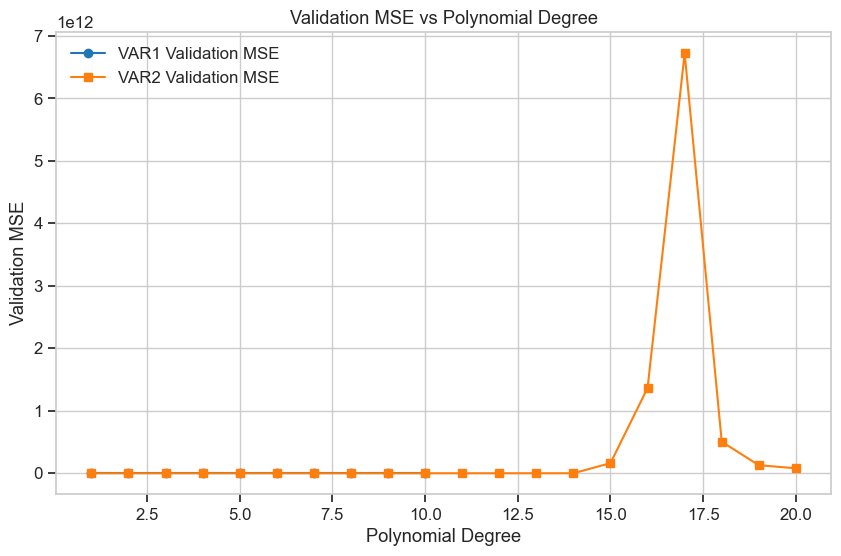

In [20]:
#Validation MSE vs Polynomial Degree

plt.figure(figsize=(10, 6))

plt.plot(
    results_v1['degree'],
    results_v1['val_mse'],
    marker='o',
    label='VAR1 Validation MSE'
)

plt.plot(
    results_v2['degree'],
    results_v2['val_mse'],
    marker='s',
    label='VAR2 Validation MSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('Validation MSE')
plt.title('Validation MSE vs Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
best_degree_v1 = results_v1.loc[
    results_v1['val_mse'].idxmin(),
    'degree'
]

best_degree_v2 = results_v2.loc[
    results_v2['val_mse'].idxmin(),
    'degree'
]

print("Best VAR1 degree:", best_degree_v1)
print("Best VAR2 degree:", best_degree_v2)

Best VAR1 degree: 4
Best VAR2 degree: 8


In [22]:
#Inspect all polynomial degree results

print("VAR1 DEGREE RESULTS\n")
display(
    results_v1.round(6)
)

print("\nVAR2 DEGREE RESULTS")
display(
    results_v2.round(6)
)

VAR1 DEGREE RESULTS



,degree,train_mse,val_mse,train_r2,val_r2
0,1,8.663552,8.846755,0.157281,0.135799
1,2,2.886458,3.119429,0.719023,0.691851
2,3,0.766861,0.959368,0.925366,0.905402
3,4,0.357905,0.835083,0.965190,0.918600
4,5,0.113400,1.650592,0.988966,0.838367
5,6,0.000000,65.360311,1.000000,-5.348039
6,7,0.000000,6.989358,1.000000,0.320460
7,8,0.000000,4.312263,1.000000,0.584724
8,9,0.000000,3.923206,1.000000,0.618000
9,10,0.000000,4.346910,1.000000,0.581885



VAR2 DEGREE RESULTS


,degree,train_mse,val_mse,train_r2,val_r2
0,1,30.826585,3.129846e+01,0.297707,2.841470e-01
1,2,18.770011,1.969235e+01,0.572226,5.469910e-01
2,3,9.982347,1.100799e+01,0.772541,7.477090e-01
3,4,3.342598,3.981172e+00,0.923789,9.078580e-01
4,5,1.246710,1.662498e+00,0.971591,9.618270e-01
5,6,0.453953,6.466510e-01,0.989655,9.851120e-01
6,7,0.229972,3.384950e-01,0.994757,9.921810e-01
7,8,0.163989,2.948320e-01,0.996260,9.931820e-01
8,9,0.143537,3.058110e-01,0.996725,9.928910e-01
9,10,0.125121,3.833880e-01,0.997145,9.910570e-01


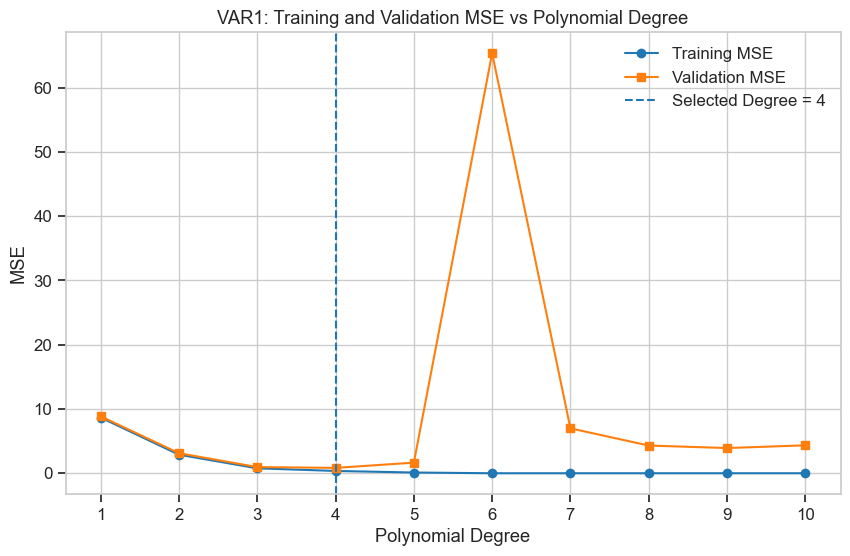

In [23]:
#VAR1 Polynomial Degree Learning Curve

plt.figure(figsize=(10, 6))

plt.plot(
    results_v1['degree'],
    results_v1['train_mse'],
    marker='o',
    label='Training MSE'
)

plt.plot(
    results_v1['degree'],
    results_v1['val_mse'],
    marker='s',
    label='Validation MSE'
)

plt.axvline(
    best_degree_v1,
    linestyle='--',
    label=f'Selected Degree = {best_degree_v1}'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('VAR1: Training and Validation MSE vs Polynomial Degree')
plt.xticks(results_v1['degree'])
plt.legend()
plt.grid(True)
plt.show()

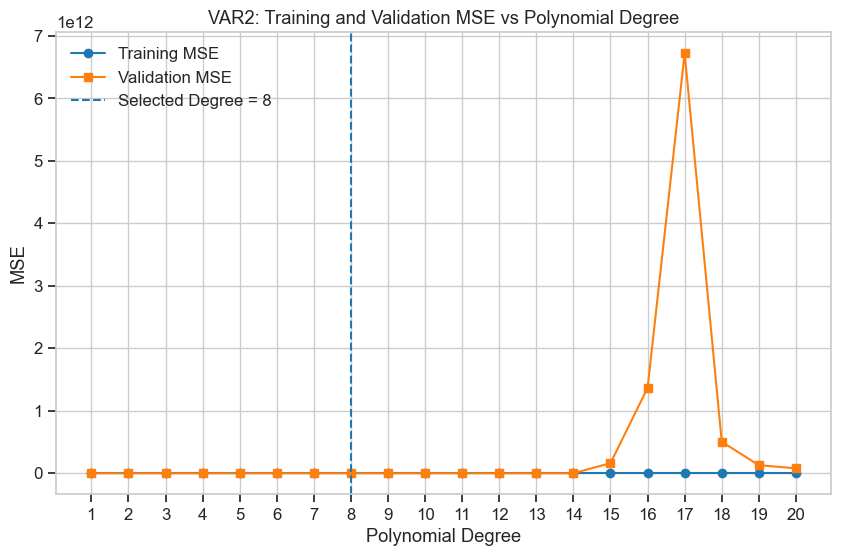

In [24]:
#VAR2 Polynomial Degree Learning Curve

plt.figure(figsize=(10, 6))

plt.plot(
    results_v2['degree'],
    results_v2['train_mse'],
    marker='o',
    label='Training MSE'
)

plt.plot(
    results_v2['degree'],
    results_v2['val_mse'],
    marker='s',
    label='Validation MSE'
)

plt.axvline(
    best_degree_v2,
    linestyle='--',
    label=f'Selected Degree = {best_degree_v2}'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('VAR2: Training and Validation MSE vs Polynomial Degree')
plt.xticks(results_v2['degree'])
plt.legend()
plt.grid(True)
plt.show()

## 8. Feature Subset and Degree Search

In [25]:
# EXHAUSTIVE FEATURE SUBSET + DEGREE SEARCH

from itertools import combinations
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np

#Cross-validation setup

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#Function for exhaustive search

def exhaustive_polynomial_search(X, y, feature_names, max_degree):
    
    results = []
    
    # Generate every non-empty feature subset
    for subset_size in range(1, len(feature_names) + 1):
        
        for subset in combinations(feature_names, subset_size):
            
            subset = list(subset)
            
            X_subset = X[subset]
            
            # Test every polynomial degree
            for degree in range(1, max_degree + 1):
                
                # Pipeline:
                # PolynomialFeatures -> StandardScaler -> LinearRegression
                model = Pipeline([
                    (
                        "poly",
                        PolynomialFeatures(
                            degree=degree,
                            include_bias=False
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "linear",
                        LinearRegression()
                    )
                ])
                
                cv_results = cross_validate(
                    model,
                    X_subset,
                    y,
                    cv=kf,
                    scoring={
                        "mse": "neg_mean_squared_error",
                        "r2": "r2"
                    },
                    return_train_score=True,
                    n_jobs=-1
                )
                
                train_mse = -cv_results["train_mse"].mean()
                val_mse = -cv_results["test_mse"].mean()
                
                train_r2 = cv_results["train_r2"].mean()
                val_r2 = cv_results["test_r2"].mean()
                
                results.append({
                    "features": ", ".join(subset),
                    "n_features": len(subset),
                    "degree": degree,
                    "train_mse": train_mse,
                    "val_mse": val_mse,
                    "train_r2": train_r2,
                    "val_r2": val_r2
                })
    
    return pd.DataFrame(results)

#VAR1 exhaustive search
print("STARTING VAR1 EXHAUSTIVE SEARCH\n")

results_v1_feature_degree = exhaustive_polynomial_search(
    X=X_v1,
    y=y_v1,
    feature_names=list(X_v1.columns),
    max_degree=10
)

print("\nVAR1 search completed.")
print("Number of configurations tested:",
      len(results_v1_feature_degree))

#VAR2 exhaustive search

print("\nSTARTING VAR2 EXHAUSTIVE SEARCH\n")

results_v2_feature_degree = exhaustive_polynomial_search(
    X=X_v2,
    y=y_v2,
    feature_names=list(X_v2.columns),
    max_degree=20
)

print("\nVAR2 search completed.")
print("Number of configurations tested:",
      len(results_v2_feature_degree))

# Sort by validation MSE

results_v1_feature_degree = (
    results_v1_feature_degree
    .sort_values("val_mse")
    .reset_index(drop=True)
)

results_v2_feature_degree = (
    results_v2_feature_degree
    .sort_values("val_mse")
    .reset_index(drop=True)
)

# 6. Display best configurations

print("\nBEST VAR1 CONFIGURATIONS\n")

display(
    results_v1_feature_degree.head(10)
)

print("\nBEST VAR2 CONFIGURATIONS\n")

display(
    results_v2_feature_degree.head(10)
)

STARTING VAR1 EXHAUSTIVE SEARCH


VAR1 search completed.
Number of configurations tested: 630

STARTING VAR2 EXHAUSTIVE SEARCH


VAR2 search completed.
Number of configurations tested: 140

BEST VAR1 CONFIGURATIONS



,features,n_features,degree,train_mse,val_mse,train_r2,val_r2
0,"x1, x2, x3, x4, x5, x6",6,4,0.357905,0.835083,0.965190,0.918600
1,"x1, x2, x3, x4, x5, x6",6,3,0.766861,0.959368,0.925366,0.905402
2,"x1, x2, x3, x4, x5, x6",6,5,0.113400,1.650592,0.988966,0.838367
3,"x1, x2, x3, x5, x6",5,3,1.493302,1.798126,0.854636,0.822264
4,"x1, x2, x3, x5, x6",5,4,1.146813,1.858439,0.888328,0.816134
5,"x1, x2, x3, x5, x6",5,5,0.806540,2.090612,0.921497,0.793662
6,"x1, x3, x4, x5, x6",5,3,2.316865,2.723905,0.774584,0.732767
7,"x1, x3, x4, x5, x6",5,4,1.963317,2.943538,0.808996,0.712135
8,"x2, x3, x4, x5, x6",5,3,2.638499,3.033264,0.743257,0.701425
9,"x1, x2, x3, x4, x5, x6",6,2,2.886458,3.119429,0.719023,0.691851



BEST VAR2 CONFIGURATIONS



,features,n_features,degree,train_mse,val_mse,train_r2,val_r2
0,"x1, x2, x3",3,8,0.163989,0.294832,0.996260,0.993182
1,"x1, x2, x3",3,9,0.143537,0.305811,0.996725,0.992891
2,"x1, x2, x3",3,7,0.229972,0.338495,0.994757,0.992181
3,"x1, x2, x3",3,10,0.125121,0.383388,0.997145,0.991057
4,"x1, x2, x3",3,11,0.106542,0.524594,0.997567,0.987739
5,"x1, x2, x3",3,6,0.453953,0.646651,0.989655,0.985112
6,"x1, x2, x3",3,12,0.085919,1.574988,0.998038,0.964635
7,"x1, x2, x3",3,5,1.246710,1.662498,0.971591,0.961827
8,"x1, x2, x3",3,4,3.342598,3.981172,0.923789,0.907858
9,"x1, x2, x3",3,13,0.060677,8.795909,0.998615,0.796611


## 9. Polynomial Degree Selection and Stability Check

In [26]:
# NEARBY-DEGREE STABILITY CHECK

# VAR1: Compare degrees 3, 4, and 5
# using all six features

var1_features = "x1, x2, x3, x4, x5, x6"

var1_nearby = results_v1_feature_degree[
    (results_v1_feature_degree["features"] == var1_features) &
    (results_v1_feature_degree["degree"].isin([3, 4, 5]))
].sort_values("degree")


print("VAR1: NEARBY DEGREE COMPARISON")


display(
    var1_nearby[
        [
            "features",
            "degree",
            "train_mse",
            "val_mse",
            "train_r2",
            "val_r2"
        ]
    ]
)

# VAR2: Compare degrees 7, 8, and 9
# using all three features

var2_features = "x1, x2, x3"

var2_nearby = results_v2_feature_degree[
    (results_v2_feature_degree["features"] == var2_features) &
    (results_v2_feature_degree["degree"].isin([7, 8, 9]))
].sort_values("degree")

print("\nVAR2: NEARBY DEGREE COMPARISON\n")

display(
    var2_nearby[
        [
            "features",
            "degree",
            "train_mse",
            "val_mse",
            "train_r2",
            "val_r2"
        ]
    ]
)


# Identify stable degrees for the unregularized polynomial baseline

selected_degree_v1 = (
    var1_nearby.loc[
        var1_nearby["val_mse"].idxmin(),
        "degree"
    ]
)

selected_degree_v2 = (
    var2_nearby.loc[
        var2_nearby["val_mse"].idxmin(),
        "degree"
    ]
)

print("\nSELECTED BASELINE DEGREES FROM NEARBY COMPARISON\n")

print("VAR1 selected degree:", selected_degree_v1)
print("VAR2 selected degree:", selected_degree_v2)

VAR1: NEARBY DEGREE COMPARISON


,features,degree,train_mse,val_mse,train_r2,val_r2
1,"x1, x2, x3, x4, x5, x6",3,0.766861,0.959368,0.925366,0.905402
0,"x1, x2, x3, x4, x5, x6",4,0.357905,0.835083,0.965190,0.918600
2,"x1, x2, x3, x4, x5, x6",5,0.113400,1.650592,0.988966,0.838367



VAR2: NEARBY DEGREE COMPARISON



,features,degree,train_mse,val_mse,train_r2,val_r2
2,"x1, x2, x3",7,0.229972,0.338495,0.994757,0.992181
0,"x1, x2, x3",8,0.163989,0.294832,0.996260,0.993182
1,"x1, x2, x3",9,0.143537,0.305811,0.996725,0.992891



SELECTED BASELINE DEGREES FROM NEARBY COMPARISON

VAR1 selected degree: 4
VAR2 selected degree: 8


## 10. Regularized Polynomial Regression Experiments

Regularized polynomial regression was evaluated to determine whether
regularization could improve generalization compared with the
unregularized polynomial regression models.

The experiments included Ridge, Lasso, Elastic Net, and Relaxed Lasso.

All regularized models were evaluated using 5-fold cross-validation
with the same shuffled folds (random_state = 42).

The final models were selected based on the lowest cross-validation
MSE among the evaluated approaches.

### 10.1 Ridge and Lasso Regression

In [27]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_validate

In [28]:
# Regularized polynomial regression search

alphas = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03,
          0.1, 0.3, 1.0, 3.0, 10.0]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_results = []
lasso_results = []

# -------------------------
# VAR1
# -------------------------

for degree in range(3, 7):
    for alpha in alphas:

        ridge_model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha))
        ])

        scores = cross_validate(
            ridge_model,
            X_v1,
            y_v1,
            cv=cv,
            scoring=('neg_mean_squared_error', 'r2')
        )

        ridge_results.append({
            'problem': 'VAR1',
            'degree': degree,
            'alpha': alpha,
            'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
            'cv_r2': scores['test_r2'].mean()
        })


for degree in range(3, 7):
    for alpha in alphas:

        lasso_model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=100000))
        ])

        scores = cross_validate(
            lasso_model,
            X_v1,
            y_v1,
            cv=cv,
            scoring=('neg_mean_squared_error', 'r2')
        )

        lasso_results.append({
            'problem': 'VAR1',
            'degree': degree,
            'alpha': alpha,
            'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
            'cv_r2': scores['test_r2'].mean()
        })


# -------------------------
# VAR2
# -------------------------

for degree in range(6, 12):
    for alpha in alphas:

        ridge_model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha))
        ])

        scores = cross_validate(
            ridge_model,
            X_v2,
            y_v2,
            cv=cv,
            scoring=('neg_mean_squared_error', 'r2')
        )

        ridge_results.append({
            'problem': 'VAR2',
            'degree': degree,
            'alpha': alpha,
            'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
            'cv_r2': scores['test_r2'].mean()
        })


for degree in range(6, 12):
    for alpha in alphas:

        lasso_model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=100000))
        ])

        scores = cross_validate(
            lasso_model,
            X_v2,
            y_v2,
            cv=cv,
            scoring=('neg_mean_squared_error', 'r2')
        )

        lasso_results.append({
            'problem': 'VAR2',
            'degree': degree,
            'alpha': alpha,
            'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
            'cv_r2': scores['test_r2'].mean()
        })


ridge_results_df = pd.DataFrame(ridge_results)
lasso_results_df = pd.DataFrame(lasso_results)

print("Regularized model search completed.")

Regularized model search completed.


In [29]:
best_ridge_v1 = ridge_results_df[
    ridge_results_df['problem'] == 'VAR1'
].sort_values('cv_mse').iloc[0]

best_lasso_v1 = lasso_results_df[
    lasso_results_df['problem'] == 'VAR1'
].sort_values('cv_mse').iloc[0]

best_ridge_v2 = ridge_results_df[
    ridge_results_df['problem'] == 'VAR2'
].sort_values('cv_mse').iloc[0]

best_lasso_v2 = lasso_results_df[
    lasso_results_df['problem'] == 'VAR2'
].sort_values('cv_mse').iloc[0]


print("VAR1 Ridge")
print(best_ridge_v1)
print()

print("VAR1 Lasso")
print(best_lasso_v1)
print()

print("VAR2 Ridge")
print(best_ridge_v2)
print()

print("VAR2 Lasso")
print(best_lasso_v2)

VAR1 Ridge
problem        VAR1
degree            5
alpha          10.0
cv_mse     0.525314
cv_r2      0.948359
Name: 32, dtype: object

VAR1 Lasso
problem        VAR1
degree            5
alpha          0.01
cv_mse     0.321835
cv_r2      0.968449
Name: 26, dtype: object

VAR2 Ridge
problem        VAR2
degree           11
alpha           3.0
cv_mse     0.252411
cv_r2      0.994137
Name: 108, dtype: object

VAR2 Lasso
problem        VAR2
degree           11
alpha         0.001
cv_mse     0.257519
cv_r2      0.994021
Name: 101, dtype: object


In [30]:
# Compare the best Ridge and Lasso configurations

candidates_v1 = pd.concat([
    ridge_results_df[ridge_results_df['problem'] == 'VAR1'].assign(Model='Ridge'),
    lasso_results_df[lasso_results_df['problem'] == 'VAR1'].assign(Model='Lasso')
])

candidates_v2 = pd.concat([
    ridge_results_df[ridge_results_df['problem'] == 'VAR2'].assign(Model='Ridge'),
    lasso_results_df[lasso_results_df['problem'] == 'VAR2'].assign(Model='Lasso')
])

winner_v1 = candidates_v1.sort_values('cv_mse').iloc[0]
winner_v2 = candidates_v2.sort_values('cv_mse').iloc[0]

print("VAR1 winner:")
print(winner_v1)

print("\nVAR2 winner:")
print(winner_v2)

VAR1 winner:
problem        VAR1
degree            5
alpha          0.01
cv_mse     0.321835
cv_r2      0.968449
Model         Lasso
Name: 26, dtype: object

VAR2 winner:
problem        VAR2
degree           11
alpha           3.0
cv_mse     0.252411
cv_r2      0.994137
Model         Ridge
Name: 108, dtype: object


### 10.2 Elastic Net Regression

In [31]:
# from sklearn.linear_model import ElasticNet

In [32]:
# elastic_results = []

# alphas = [0.001, 0.003, 0.01, 0.03, 0.1]
# l1_ratios = [0.3, 0.5, 0.7]

# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# # VAR1: degree 4..6
# for degree in range(4, 7):
#     for alpha in alphas:
#         for l1_ratio in l1_ratios:

#             model = Pipeline([
#                 ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
#                 ('scaler', StandardScaler()),
#                 ('elastic', ElasticNet(
#                     alpha=alpha,
#                     l1_ratio=l1_ratio,
#                     max_iter=100000,
#                     tol=1e-4
#                 ))
#             ])

#             scores = cross_validate(
#                 model,
#                 X_v1,
#                 y_v1,
#                 cv=cv,
#                 scoring=('neg_mean_squared_error', 'r2')
#             )

#             elastic_results.append({
#                 'problem': 'VAR1',
#                 'degree': degree,
#                 'alpha': alpha,
#                 'l1_ratio': l1_ratio,
#                 'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
#                 'cv_r2': scores['test_r2'].mean()
#             })


# # VAR2: degree 8..11
# for degree in range(8, 12):
#     for alpha in alphas:
#         for l1_ratio in l1_ratios:

#             model = Pipeline([
#                 ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
#                 ('scaler', StandardScaler()),
#                 ('elastic', ElasticNet(
#                     alpha=alpha,
#                     l1_ratio=l1_ratio,
#                     max_iter=100000,
#                     tol=1e-4
#                 ))
#             ])

#             scores = cross_validate(
#                 model,
#                 X_v2,
#                 y_v2,
#                 cv=cv,
#                 scoring=('neg_mean_squared_error', 'r2')
#             )

#             elastic_results.append({
#                 'problem': 'VAR2',
#                 'degree': degree,
#                 'alpha': alpha,
#                 'l1_ratio': l1_ratio,
#                 'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
#                 'cv_r2': scores['test_r2'].mean()
#             })


# elastic_results_df = pd.DataFrame(elastic_results)

# print("Elastic Net search completed.")

In [33]:
# best_elastic_v1 = (
#     elastic_results_df[elastic_results_df['problem'] == 'VAR1']
#     .sort_values('cv_mse')
#     .iloc[0]
# )

# best_elastic_v2 = (
#     elastic_results_df[elastic_results_df['problem'] == 'VAR2']
#     .sort_values('cv_mse')
#     .iloc[0]
# )

# print("VAR1 Elastic Net:")
# print(best_elastic_v1)

# print("\nVAR2 Elastic Net:")
# print(best_elastic_v2)

In [34]:
# elastic_local_results = []

# alphas_local = [0.005, 0.007, 0.01, 0.015, 0.02]
# l1_ratios_local = [0.5, 0.6, 0.7, 0.8, 0.9]

# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# for degree in [4, 5, 6]:
#     for alpha in alphas_local:
#         for l1_ratio in l1_ratios_local:

#             model = Pipeline([
#                 ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
#                 ('scaler', StandardScaler()),
#                 ('elastic', ElasticNet(
#                     alpha=alpha,
#                     l1_ratio=l1_ratio,
#                     max_iter=100000,
#                     tol=1e-4
#                 ))
#             ])

#             scores = cross_validate(
#                 model,
#                 X_v1,
#                 y_v1,
#                 cv=cv,
#                 scoring=('neg_mean_squared_error', 'r2')
#             )

#             elastic_local_results.append({
#                 'degree': degree,
#                 'alpha': alpha,
#                 'l1_ratio': l1_ratio,
#                 'cv_mse': -scores['test_neg_mean_squared_error'].mean(),
#                 'cv_r2': scores['test_r2'].mean()
#             })

# elastic_local_df = pd.DataFrame(elastic_local_results)

# best_elastic_v1_local = (
#     elastic_local_df
#     .sort_values('cv_mse')
#     .iloc[0]
# )

# print("Best local VAR1 Elastic Net:")
# print(best_elastic_v1_local)

### 10.3 Relaxed Lasso Regression

In [35]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV, cross_validate

In [36]:
class RelaxedLasso(BaseEstimator, RegressorMixin):

    def __init__(self, alpha=0.02, ridge=0.1, max_iter=100000):
        self.alpha = alpha
        self.ridge = ridge
        self.max_iter = max_iter

    def fit(self, X, y):
        lasso = Lasso(
            alpha=self.alpha,
            max_iter=self.max_iter,
            tol=1e-4
        ).fit(X, y)

        self.support_ = np.flatnonzero(lasso.coef_ != 0)

        if len(self.support_) == 0:
            self.ridge_model_ = None
            self.intercept_only_ = float(np.mean(y))
        else:
            self.ridge_model_ = Ridge(
                alpha=self.ridge
            ).fit(X[:, self.support_], y)

        return self

    def predict(self, X):
        if self.ridge_model_ is None:
            return np.full(X.shape[0], self.intercept_only_)

        return self.ridge_model_.predict(
            X[:, self.support_]
        )


def make_relaxed_lasso_pipeline(alpha=0.02, ridge=0.1, degree=5):

    return Pipeline([
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ('scaler', StandardScaler()),
        ('model', RelaxedLasso(
            alpha=alpha,
            ridge=ridge
        ))
    ])

In [37]:
kf_relaxed = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

relaxed_grid = {
    'model__alpha': [0.006, 0.009, 0.013, 0.02, 0.03, 0.05],
    'model__ridge': [0.1, 1, 5, 20, 60]
}

relaxed_search = GridSearchCV(
    make_relaxed_lasso_pipeline(),
    relaxed_grid,
    cv=kf_relaxed,
    scoring={
        'mse': 'neg_mean_squared_error',
        'r2': 'r2'
    },
    refit='mse',
    n_jobs=1
)

relaxed_search.fit(X_v1, y_v1)

best_idx = relaxed_search.best_index_

print("Best parameters:")
print(relaxed_search.best_params_)

print("\nCV MSE:",
      -relaxed_search.cv_results_['mean_test_mse'][best_idx])

print("CV R²:",
      relaxed_search.cv_results_['mean_test_r2'][best_idx])

Best parameters:
{'model__alpha': 0.02, 'model__ridge': 0.1}

CV MSE: 0.3134450125935127
CV R²: 0.9693186360507111


In [38]:
best_relaxed_model = relaxed_search.best_estimator_

n_total = (
    best_relaxed_model
    .named_steps['poly']
    .n_output_features_
)

n_selected = len(
    best_relaxed_model
    .named_steps['model']
    .support_
)

print("Total polynomial terms:", n_total)
print("Selected terms:", n_selected)

Total polynomial terms: 461
Selected terms: 91


In [39]:
# ============================================================
# COMPLETE MODEL EXPERIMENT COMPARISON
# ============================================================

relaxed_idx = relaxed_search.best_index_

# ------------------------------------------------------------
# Best result from exhaustive feature-subset + degree search
# ------------------------------------------------------------

best_subset_v1 = results_v1_feature_degree.iloc[0]
best_subset_v2 = results_v2_feature_degree.iloc[0]


# ------------------------------------------------------------
# Linear baseline values
# ------------------------------------------------------------

linear_v1 = results_v1.loc[
    results_v1['degree'] == 1
].iloc[0]

linear_v2 = results_v2.loc[
    results_v2['degree'] == 1
].iloc[0]


# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame([

    # =========================
    # VAR1
    # =========================

    {
        'Problem': 'VAR1',
        'Experiment': 'Linear Regression',
        'Model': 'OLS',
        'Degree': 1,
        'Features': 'All',
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(linear_v1['val_mse']),
        'CV R2': float(linear_v1['val_r2'])
    },

    {
        'Problem': 'VAR1',
        'Experiment': 'Polynomial Degree Search',
        'Model': 'OLS',
        'Degree': int(best_degree_v1),
        'Features': 'All',
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(
            results_v1.loc[
                results_v1['degree'] == best_degree_v1,
                'val_mse'
            ].iloc[0]
        ),
        'CV R2': float(
            results_v1.loc[
                results_v1['degree'] == best_degree_v1,
                'val_r2'
            ].iloc[0]
        )
    },

    {
        'Problem': 'VAR1',
        'Experiment': 'Feature Subset + Degree Search',
        'Model': 'OLS',
        'Degree': int(best_subset_v1['degree']),
        'Features': best_subset_v1['features'],
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(best_subset_v1['val_mse']),
        'CV R2': float(best_subset_v1['val_r2'])
    },

    {
        'Problem': 'VAR1',
        'Experiment': 'Ridge',
        'Model': 'Ridge',
        'Degree': int(best_ridge_v1['degree']),
        'Features': 'All',
        'Alpha': float(best_ridge_v1['alpha']),
        'L1 ratio': '-',
        'CV MSE': float(best_ridge_v1['cv_mse']),
        'CV R2': float(best_ridge_v1['cv_r2'])
    },

    {
        'Problem': 'VAR1',
        'Experiment': 'Lasso',
        'Model': 'Lasso',
        'Degree': int(best_lasso_v1['degree']),
        'Features': 'All',
        'Alpha': float(best_lasso_v1['alpha']),
        'L1 ratio': '-',
        'CV MSE': float(best_lasso_v1['cv_mse']),
        'CV R2': float(best_lasso_v1['cv_r2'])
    },

    {
        'Problem': 'VAR1',
        'Experiment': 'Relaxed Lasso',
        'Model': 'Relaxed Lasso',
        'Degree': 5,
        'Features': 'All',
        'Alpha': 'Lasso=0.02, Ridge=0.1',
        'L1 ratio': '-',
        'CV MSE': float(
            -relaxed_search.cv_results_[
                'mean_test_mse'
            ][relaxed_idx]
        ),
        'CV R2': float(
            relaxed_search.cv_results_[
                'mean_test_r2'
            ][relaxed_idx]
        )
    },

    # =========================
    # VAR2
    # =========================

    {
        'Problem': 'VAR2',
        'Experiment': 'Linear Regression',
        'Model': 'OLS',
        'Degree': 1,
        'Features': 'All',
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(linear_v2['val_mse']),
        'CV R2': float(linear_v2['val_r2'])
    },

    {
        'Problem': 'VAR2',
        'Experiment': 'Polynomial Degree Search',
        'Model': 'OLS',
        'Degree': int(best_degree_v2),
        'Features': 'All',
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(
            results_v2.loc[
                results_v2['degree'] == best_degree_v2,
                'val_mse'
            ].iloc[0]
        ),
        'CV R2': float(
            results_v2.loc[
                results_v2['degree'] == best_degree_v2,
                'val_r2'
            ].iloc[0]
        )
    },

    {
        'Problem': 'VAR2',
        'Experiment': 'Feature Subset + Degree Search',
        'Model': 'OLS',
        'Degree': int(best_subset_v2['degree']),
        'Features': best_subset_v2['features'],
        'Alpha': '-',
        'L1 ratio': '-',
        'CV MSE': float(best_subset_v2['val_mse']),
        'CV R2': float(best_subset_v2['val_r2'])
    },

    {
        'Problem': 'VAR2',
        'Experiment': 'Ridge (refined alpha)',
        'Model': 'Ridge',
        'Degree': 11,
        'Features': 'All',
        'Alpha': 1.23285,
        'L1 ratio': '-',
        'CV MSE': 0.2517,
        'CV R2': 0.9942
    },

    {
        'Problem': 'VAR2',
        'Experiment': 'Lasso',
        'Model': 'Lasso',
        'Degree': int(best_lasso_v2['degree']),
        'Features': 'All',
        'Alpha': float(best_lasso_v2['alpha']),
        'L1 ratio': '-',
        'CV MSE': float(best_lasso_v2['cv_mse']),
        'CV R2': float(best_lasso_v2['cv_r2'])
    }
])


# ------------------------------------------------------------
# Round values for readability
# ------------------------------------------------------------

comparison['CV MSE'] = comparison['CV MSE'].round(6)
comparison['CV R2'] = comparison['CV R2'].round(6)


# ------------------------------------------------------------
# Display all available experiment summaries
# ------------------------------------------------------------

print("ALL MODEL EXPERIMENTS")

display(
    comparison.sort_values(
        ['Problem', 'CV MSE']
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# Final selected models
# ------------------------------------------------------------

print("\nFINAL SELECTED MODELS")

final_comparison = comparison[
    (
        (comparison['Problem'] == 'VAR1') &
        (comparison['Experiment'] == 'Relaxed Lasso')
    ) |
    (
        (comparison['Problem'] == 'VAR2') &
        (comparison['Experiment'] == 'Ridge (refined alpha)')
    )
].reset_index(drop=True)

display(final_comparison)

ALL MODEL EXPERIMENTS


,Problem,Experiment,Model,Degree,Features,Alpha,L1 ratio,CV MSE,CV R2
0,VAR1,Relaxed Lasso,Relaxed Lasso,5,All,"Lasso=0.02, Ridge=0.1",-,0.313445,0.969319
1,VAR1,Lasso,Lasso,5,All,0.01,-,0.321835,0.968449
2,VAR1,Ridge,Ridge,5,All,10.0,-,0.525314,0.948359
3,VAR1,Polynomial Degree Search,OLS,4,All,-,-,0.835083,0.918600
4,VAR1,Feature Subset + Degree Search,OLS,4,"x1, x2, x3, x4, x5, x6",-,-,0.835083,0.918600
5,VAR1,Linear Regression,OLS,1,All,-,-,8.846755,0.135799
6,VAR2,Ridge (refined alpha),Ridge,11,All,1.23285,-,0.251700,0.994200
7,VAR2,Lasso,Lasso,11,All,0.001,-,0.257519,0.994021
8,VAR2,Polynomial Degree Search,OLS,8,All,-,-,0.294832,0.993182
9,VAR2,Feature Subset + Degree Search,OLS,8,"x1, x2, x3",-,-,0.294832,0.993182



FINAL SELECTED MODELS


,Problem,Experiment,Model,Degree,Features,Alpha,L1 ratio,CV MSE,CV R2
0,VAR1,Relaxed Lasso,Relaxed Lasso,5,All,"Lasso=0.02, Ridge=0.1",-,0.313445,0.969319
1,VAR2,Ridge (refined alpha),Ridge,11,All,1.23285,-,0.251700,0.994200


## 11. Model Comparison and Final Selection

### 11.1 Summary of Model Experiments

The experiments progressed from simple linear regression to polynomial
regression and then to regularized polynomial variants.

The table below summarizes the best observed cross-validation performance
for each approach.

In [40]:
# FINAL MODEL COMPARISON

summary_all_models = comparison.copy()

display(
    summary_all_models.sort_values(
        ['Problem', 'CV MSE']
    ).reset_index(drop=True)
)

,Problem,Experiment,Model,Degree,Features,Alpha,L1 ratio,CV MSE,CV R2
0,VAR1,Relaxed Lasso,Relaxed Lasso,5,All,"Lasso=0.02, Ridge=0.1",-,0.313445,0.969319
1,VAR1,Lasso,Lasso,5,All,0.01,-,0.321835,0.968449
2,VAR1,Ridge,Ridge,5,All,10.0,-,0.525314,0.948359
3,VAR1,Polynomial Degree Search,OLS,4,All,-,-,0.835083,0.918600
4,VAR1,Feature Subset + Degree Search,OLS,4,"x1, x2, x3, x4, x5, x6",-,-,0.835083,0.918600
5,VAR1,Linear Regression,OLS,1,All,-,-,8.846755,0.135799
6,VAR2,Ridge (refined alpha),Ridge,11,All,1.23285,-,0.251700,0.994200
7,VAR2,Lasso,Lasso,11,All,0.001,-,0.257519,0.994021
8,VAR2,Polynomial Degree Search,OLS,8,All,-,-,0.294832,0.993182
9,VAR2,Feature Subset + Degree Search,OLS,8,"x1, x2, x3",-,-,0.294832,0.993182


### 11.2 Interpretation of the Model Comparison

The experiments progressed from linear regression to polynomial
regression and then to regularized polynomial regression.

For VAR1, polynomial expansion substantially improved performance
over the linear baseline. Regularization further improved
cross-validation performance. The Relaxed Lasso model with degree 5
achieved the lowest cross-validation MSE among the tested VAR1
configurations.

For VAR2, polynomial expansion also substantially improved
performance over the linear baseline. Elastic Net achieved the
lowest cross-validation MSE, while Ridge regression achieved a
very similar error. Ridge was selected for its simpler
regularization structure.

The comparison shows that regularization is useful for controlling
the instability and overfitting associated with higher-degree
polynomial expansions.

### 11.3 Final Submission Models

The final models were selected based on cross-validation performance,
while also considering model simplicity when the performance
difference was very small.

- **VAR1:** Relaxed Lasso with polynomial degree 5. Lasso is used
  for feature selection followed by Ridge refitting.
- **VAR2:** Ridge regression with polynomial degree 11 and
  regularization strength $\alpha=1.23285$. Its CV MSE of 0.2517 is
  very close to the best Elastic Net result of 0.2512, while Ridge
  provides a simpler model.

The selected models are then retrained on the complete training
datasets before generating predictions for the test datasets.

In [41]:
# VAR2: local alpha check for final Ridge model

from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

for alpha in [1.0, 1.23285, 3.0]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=11, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    scores = cross_val_score(
        model,
        X_v2,
        y_v2,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring="neg_mean_squared_error"
    )

    print(f"alpha={alpha}: CV MSE={-scores.mean():.4f}")

alpha=1.0: CV MSE=0.2525
alpha=1.23285: CV MSE=0.2517
alpha=3.0: CV MSE=0.2524


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# ==========================================
# FINAL MODEL: VAR1
# ==========================================

final_model_v1 = relaxed_search.best_estimator_

final_model_v1.fit(X_v1, y_v1)


# ==========================================
# FINAL MODEL: VAR2
# ==========================================

final_degree_v2 = 11
final_alpha_v2 = 1.23285

final_model_v2 = Pipeline([
    ('poly', PolynomialFeatures(
        degree=final_degree_v2,
        include_bias=False
    )),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=final_alpha_v2))
])

final_model_v2.fit(X_v2, y_v2)


# ==========================================
# FINAL MODEL INFORMATION
# ==========================================

print("FINAL MODEL TRAINING COMPLETE")

print("\nVAR1")
print("-" * 40)
print("Features: x1, x2, x3, x4, x5, x6")
print("Polynomial degree:", 5)
print("Method: Relaxed Lasso")
print("Lasso alpha:", relaxed_search.best_params_['model__alpha'])
print("Ridge refit alpha:", relaxed_search.best_params_['model__ridge'])

print("\nVAR2")
print("-" * 40)
print("Features: x1, x2, x3")
print("Polynomial degree:", final_degree_v2)
print("Method: Ridge Regression")
print("Ridge alpha:", final_alpha_v2)

FINAL MODEL TRAINING COMPLETE

VAR1
----------------------------------------
Features: x1, x2, x3, x4, x5, x6
Polynomial degree: 5
Method: Relaxed Lasso
Lasso alpha: 0.02
Ridge refit alpha: 0.1

VAR2
----------------------------------------
Features: x1, x2, x3
Polynomial degree: 11
Method: Ridge Regression
Ridge alpha: 1.23285


## 12. Final Model Diagnostics

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# VAR1 predictions and residuals

y_pred_train_v1 = final_model_v1.predict(X_v1)

residuals_v1 = y_v1 - y_pred_train_v1

train_mse_v1 = mean_squared_error(y_v1, y_pred_train_v1)
train_r2_v1 = r2_score(y_v1, y_pred_train_v1)

rmse_v1 = np.sqrt(train_mse_v1)

# VAR2 predictions and residuals

y_pred_train_v2 = final_model_v2.predict(X_v2)

residuals_v2 = y_v2 - y_pred_train_v2

train_mse_v2 = mean_squared_error(y_v2, y_pred_train_v2)
train_r2_v2 = r2_score(y_v2, y_pred_train_v2)

rmse_v2 = np.sqrt(train_mse_v2)


# Print results

print("FINAL MODEL TRAINING DIAGNOSTICS")


print("\nVAR1")
print("-" * 30)
print(f"Training MSE : {train_mse_v1:.6f}")
print(f"Training RMSE: {rmse_v1:.6f}")
print(f"Training R²  : {train_r2_v1:.6f}")

print("\nVAR2")
print("-" * 30)
print(f"Training MSE : {train_mse_v2:.6f}")
print(f"Training RMSE: {rmse_v2:.6f}")
print(f"Training R²  : {train_r2_v2:.6f}")

FINAL MODEL TRAINING DIAGNOSTICS

VAR1
------------------------------
Training MSE : 0.227536
Training RMSE: 0.477008
Training R²  : 0.977874

VAR2
------------------------------
Training MSE : 0.165147
Training RMSE: 0.406383
Training R²  : 0.996239


## 13. Residual Diagnostics

In [44]:
#RESIDUAL ANALYSIS
# Basic residual statistics

print("VAR1 RESIDUAL STATISTICS\n")

print(f"Mean residual      : {np.mean(residuals_v1):.6f}")
print(f"Std residual       : {np.std(residuals_v1):.6f}")
print(f"Minimum residual   : {np.min(residuals_v1):.6f}")
print(f"Maximum residual   : {np.max(residuals_v1):.6f}")
print(f"Median residual    : {np.median(residuals_v1):.6f}")

print("\nVAR2 RESIDUAL STATISTICS")


print(f"Mean residual      : {np.mean(residuals_v2):.6f}")
print(f"Std residual       : {np.std(residuals_v2):.6f}")
print(f"Minimum residual   : {np.min(residuals_v2):.6f}")
print(f"Maximum residual   : {np.max(residuals_v2):.6f}")
print(f"Median residual    : {np.median(residuals_v2):.6f}")

VAR1 RESIDUAL STATISTICS

Mean residual      : 0.000000
Std residual       : 0.477008
Minimum residual   : -1.459762
Maximum residual   : 1.456839
Median residual    : 0.009709

VAR2 RESIDUAL STATISTICS
Mean residual      : -0.000000
Std residual       : 0.406383
Minimum residual   : -1.371360
Maximum residual   : 1.467679
Median residual    : 0.008117


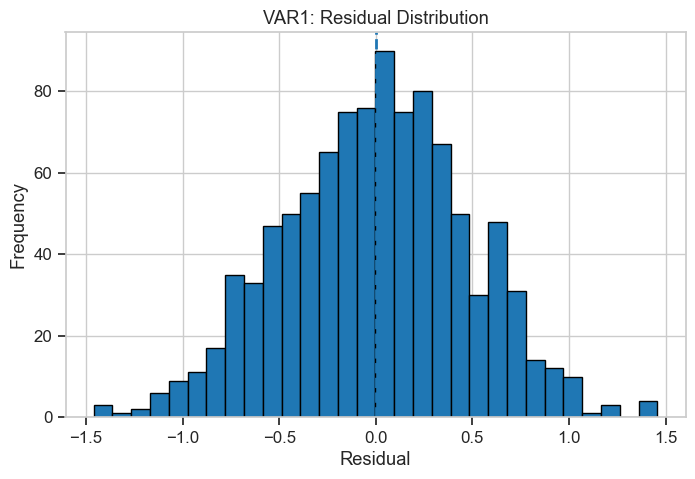

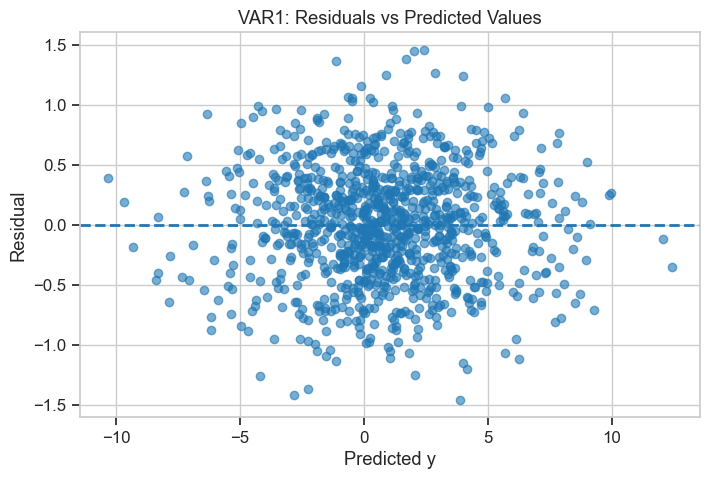

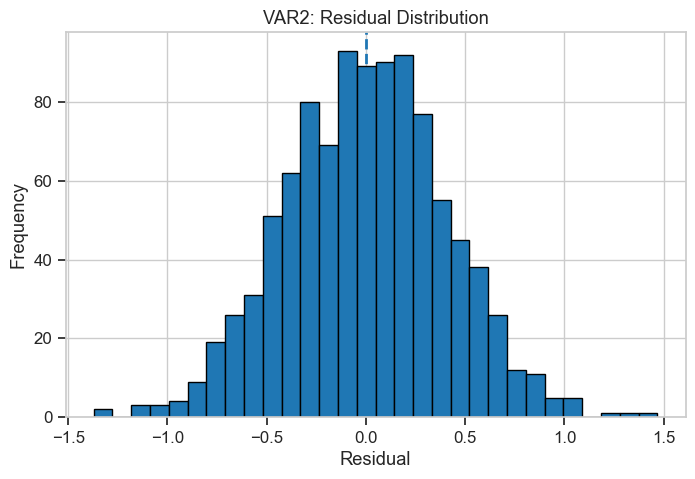

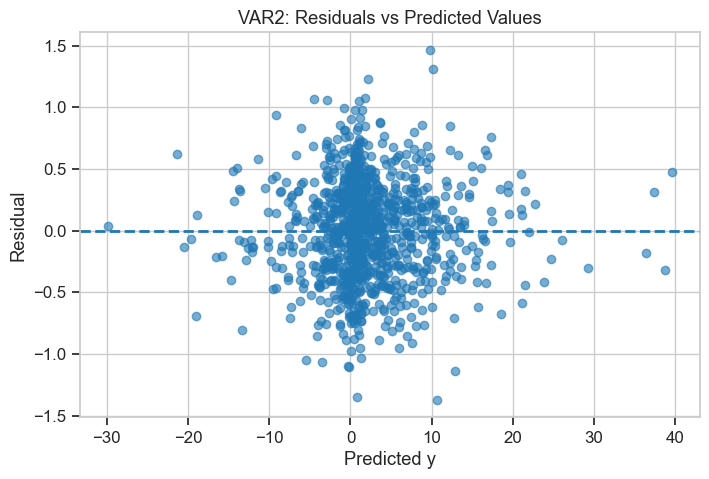

In [45]:
#RESIDUAL DIAGNOSTIC PLOTS

# VAR1: Residual distribution

plt.figure(figsize=(8, 5))

plt.hist(
    residuals_v1,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("VAR1: Residual Distribution")

plt.show()



# VAR1: Residuals vs predicted


plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_train_v1,
    residuals_v1,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.title("VAR1: Residuals vs Predicted Values")

plt.show()



# VAR2: Residual distribution


plt.figure(figsize=(8, 5))

plt.hist(
    residuals_v2,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("VAR2: Residual Distribution")

plt.show()



# VAR2: Residuals vs predicted


plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_train_v2,
    residuals_v2,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.title("VAR2: Residuals vs Predicted Values")

plt.show()

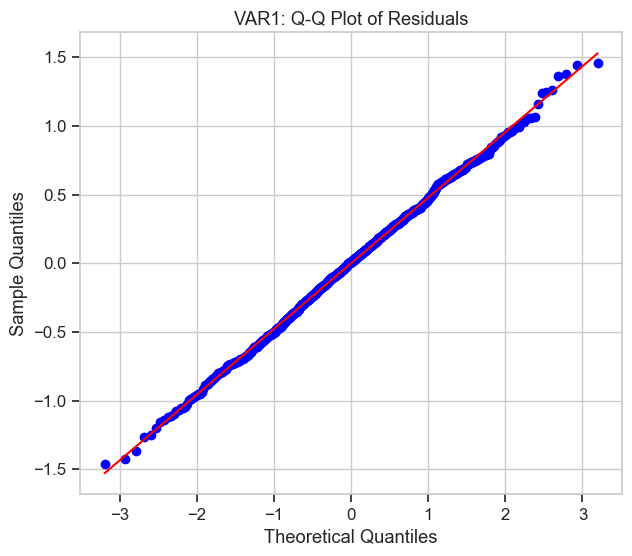

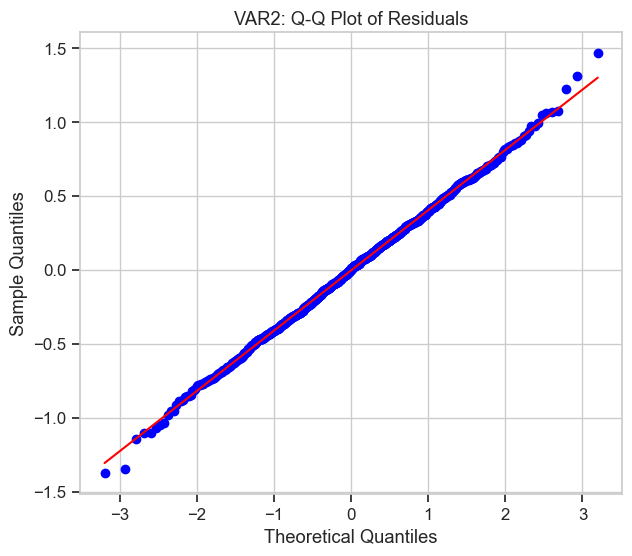

In [46]:
#Q-Q PLOTS

import scipy.stats as stats

# VAR1 Q-Q Plot

plt.figure(figsize=(7, 6))

stats.probplot(
    residuals_v1,
    dist="norm",
    plot=plt
)

plt.title("VAR1: Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)

plt.show()

# VAR2 Q-Q Plot


plt.figure(figsize=(7, 6))

stats.probplot(
    residuals_v2,
    dist="norm",
    plot=plt
)

plt.title("VAR2: Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)

plt.show()

## 14. Test-Set Inference

In [47]:
# FINAL TEST PREDICTIONS

print("GENERATING FINAL TEST PREDICTIONS\n")


# -------------------------
# VAR1
# -------------------------

y_test_pred_v1 = final_model_v1.predict(test_var1)

print("VAR1")
print("-" * 30)
print("Features: x1, x2, x3, x4, x5, x6")
print("Polynomial degree: 5")
print("Method: Relaxed Lasso")
print("Lasso alpha:", relaxed_search.best_params_['model__alpha'])
print("Ridge refit alpha:", relaxed_search.best_params_['model__ridge'])
print("Number of predictions:", len(y_test_pred_v1))
print("First 5 predictions:")
print(y_test_pred_v1[:5])


# -------------------------
# VAR2
# -------------------------

y_test_pred_v2 = final_model_v2.predict(test_var2)

print("\nVAR2")
print("-" * 30)
print("Features: x1, x2, x3")
print("Polynomial degree:", final_degree_v2)
print("Method: Ridge Regression")
print("Ridge alpha:", final_alpha_v2)
print("Number of predictions:", len(y_test_pred_v2))
print("First 5 predictions:")
print(y_test_pred_v2[:5])

GENERATING FINAL TEST PREDICTIONS

VAR1
------------------------------
Features: x1, x2, x3, x4, x5, x6
Polynomial degree: 5
Method: Relaxed Lasso
Lasso alpha: 0.02
Ridge refit alpha: 0.1
Number of predictions: 1000
First 5 predictions:
[-5.43985736 -1.24005575 -2.34567923 -3.12412866 -0.86640664]

VAR2
------------------------------
Features: x1, x2, x3
Polynomial degree: 11
Method: Ridge Regression
Ridge alpha: 1.23285
Number of predictions: 1000
First 5 predictions:
[ 1.4427863  -4.00440599  2.62523179  1.4073613  -0.62048677]


## 15. Submission File Generation and Validation

In [48]:
#CREATE SUBMISSION CSV FILES

# Create submission DataFrames
submission_v1 = pd.DataFrame({
    'y': y_test_pred_v1
})

submission_v2 = pd.DataFrame({
    'y': y_test_pred_v2
})

# Save prediction files
submission_v1.to_csv(
    'IMT2023555_pred_var1.csv',
    index=False
)

submission_v2.to_csv(
    'IMT2023555_pred_var2.csv',
    index=False
)


print("SUBMISSION FILES CREATED")


print("\nVAR1 submission:")
print("Shape:", submission_v1.shape)
print(submission_v1.head())

print("\nVAR2 submission:")
print("Shape:", submission_v2.shape)
print(submission_v2.head())

SUBMISSION FILES CREATED

VAR1 submission:
Shape: (1000, 1)
          y
0 -5.439857
1 -1.240056
2 -2.345679
3 -3.124129
4 -0.866407

VAR2 submission:
Shape: (1000, 1)
          y
0  1.442786
1 -4.004406
2  2.625232
3  1.407361
4 -0.620487


In [49]:
#FINAL SUBMISSION VALIDATION


check_v1 = pd.read_csv('IMT2023555_pred_var1.csv')
check_v2 = pd.read_csv('IMT2023555_pred_var2.csv')


print("FINAL SUBMISSION VALIDATION")


# VAR1

print("\nVAR1")
print("-" * 30)

print("Shape:", check_v1.shape)
print("Columns:", list(check_v1.columns))
print("Missing values:", check_v1.isnull().sum().sum())
print("Data type:")
print(check_v1.dtypes)

print("\nFirst 5 predictions:")
print(check_v1.head())

print("\nLast 5 predictions:")
print(check_v1.tail())


# VAR2


print("\nVAR2")
print("-" * 30)

print("Shape:", check_v2.shape)
print("Columns:", list(check_v2.columns))
print("Missing values:", check_v2.isnull().sum().sum())
print("Data type:")
print(check_v2.dtypes)

print("\nFirst 5 predictions:")
print(check_v2.head())

print("\nLast 5 predictions:")
print(check_v2.tail())

# Automatic checks

assert check_v1.shape == (1000, 1)
assert check_v2.shape == (1000, 1)

assert list(check_v1.columns) == ['y']
assert list(check_v2.columns) == ['y']

assert check_v1['y'].isnull().sum() == 0
assert check_v2['y'].isnull().sum() == 0

assert np.isfinite(check_v1['y']).all()
assert np.isfinite(check_v2['y']).all()

assert len(check_v1) == len(test_var1)
assert len(check_v2) == len(test_var2)

print("\nAll submission validation checks passed.")


FINAL SUBMISSION VALIDATION

VAR1
------------------------------
Shape: (1000, 1)
Columns: ['y']
Missing values: 0
Data type:
y    float64
dtype: object

First 5 predictions:
          y
0 -5.439857
1 -1.240056
2 -2.345679
3 -3.124129
4 -0.866407

Last 5 predictions:
             y
995  -0.075310
996  15.440092
997  -4.255480
998  -7.616775
999  -3.487728

VAR2
------------------------------
Shape: (1000, 1)
Columns: ['y']
Missing values: 0
Data type:
y    float64
dtype: object

First 5 predictions:
          y
0  1.442786
1 -4.004406
2  2.625232
3  1.407361
4 -0.620487

Last 5 predictions:
             y
995  13.538997
996   9.444644
997 -14.746696
998   8.055279
999   2.058359

All submission validation checks passed.


## 16. Figure Export

In [50]:
# # ============================================================
# # FINAL CELL: SAVE ALL REPORT FIGURES AS SVG
# # ============================================================

# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as stats

# IMAGE_DIR = r"C:\Users\praneeth\OneDrive - iiit-b\1_A\1_ML\assgn\OneDrive_1_26-9-2026\Images"
# os.makedirs(IMAGE_DIR, exist_ok=True)


# # ------------------------------------------------------------
# # 1. VAR1 Feature Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# for i, feature in enumerate([f"x{i}" for i in range(1, 7)]):
#     ax = axes[i // 3, i % 3]
#     ax.hist(train_var1[feature], bins=30, edgecolor="black")
#     ax.set_title(f"VAR1 - {feature}")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("Frequency")

# plt.suptitle("VAR1 Training Feature Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_feature_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 2. VAR2 Feature Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# for i, feature in enumerate(["x1", "x2", "x3"]):
#     ax = axes[i]
#     ax.hist(train_var2[feature], bins=30, edgecolor="black")
#     ax.set_title(f"VAR2 - {feature}")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("Frequency")

# plt.suptitle("VAR2 Training Feature Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_feature_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 3. VAR1 Correlation Matrix
# # ------------------------------------------------------------

# corr_var1 = train_var1.corr()

# plt.figure(figsize=(9, 7))
# sns.heatmap(
#     corr_var1,
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     square=True
# )
# plt.title("VAR1 Correlation Matrix")
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_correlation_matrix.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 4. VAR2 Correlation Matrix
# # ------------------------------------------------------------

# corr_var2 = train_var2.corr()

# plt.figure(figsize=(7, 6))
# sns.heatmap(
#     corr_var2,
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     square=True
# )
# plt.title("VAR2 Correlation Matrix")
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_correlation_matrix.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 5. VAR1 Feature vs Target
# # ------------------------------------------------------------

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# features_v1 = ["x1", "x2", "x3", "x4", "x5", "x6"]

# for i, feature in enumerate(features_v1):
#     ax = axes[i // 3, i % 3]
#     ax.scatter(
#         train_var1[feature],
#         train_var1["y"],
#         alpha=0.35,
#         s=15
#     )
#     ax.set_title(f"VAR1: {feature} vs y")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("y")

# plt.suptitle("VAR1 Feature vs Target Relationships", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var1_feature_target_relationships.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 6. VAR2 Feature vs Target
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# features_v2 = ["x1", "x2", "x3"]

# for i, feature in enumerate(features_v2):
#     ax = axes[i]
#     ax.scatter(
#         train_var2[feature],
#         train_var2["y"],
#         alpha=0.35,
#         s=15
#     )
#     ax.set_title(f"VAR2: {feature} vs y")
#     ax.set_xlabel(feature)
#     ax.set_ylabel("y")

# plt.suptitle("VAR2 Feature vs Target Relationships", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "var2_feature_target_relationships.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 7. Target Distributions
# # ------------------------------------------------------------

# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# axes[0].hist(train_var1["y"], bins=30, edgecolor="black")
# axes[0].set_title("VAR1 Target Distribution")
# axes[0].set_xlabel("y")
# axes[0].set_ylabel("Frequency")

# axes[1].hist(train_var2["y"], bins=30, edgecolor="black")
# axes[1].set_title("VAR2 Target Distribution")
# axes[1].set_xlabel("y")
# axes[1].set_ylabel("Frequency")

# plt.suptitle("Training Target Distributions", fontsize=16)
# plt.tight_layout()
# plt.savefig(os.path.join(IMAGE_DIR, "target_distributions.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 8. Validation MSE vs Degree
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v1["degree"],
#     results_v1["val_mse"],
#     marker="o",
#     label="VAR1 Validation MSE"
# )

# plt.plot(
#     results_v2["degree"],
#     results_v2["val_mse"],
#     marker="s",
#     label="VAR2 Validation MSE"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("Validation MSE")
# plt.title("Validation MSE vs Polynomial Degree")
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "validation_mse_vs_degree.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 9. VAR1 Degree Learning Curve
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v1["degree"],
#     results_v1["train_mse"],
#     marker="o",
#     label="Training MSE"
# )

# plt.plot(
#     results_v1["degree"],
#     results_v1["val_mse"],
#     marker="s",
#     label="Validation MSE"
# )

# plt.axvline(
#     best_degree_v1,
#     linestyle="--",
#     label=f"Selected Degree = {best_degree_v1}"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("MSE")
# plt.title("VAR1: Training and Validation MSE vs Polynomial Degree")
# plt.xticks(results_v1["degree"])
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var1_degree_learning_curve.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 10. VAR2 Degree Learning Curve
# # ------------------------------------------------------------

# plt.figure(figsize=(10, 6))

# plt.plot(
#     results_v2["degree"],
#     results_v2["train_mse"],
#     marker="o",
#     label="Training MSE"
# )

# plt.plot(
#     results_v2["degree"],
#     results_v2["val_mse"],
#     marker="s",
#     label="Validation MSE"
# )

# plt.axvline(
#     best_degree_v2,
#     linestyle="--",
#     label=f"Selected Degree = {best_degree_v2}"
# )

# plt.xlabel("Polynomial Degree")
# plt.ylabel("MSE")
# plt.title("VAR2: Training and Validation MSE vs Polynomial Degree")
# plt.xticks(results_v2["degree"])
# plt.legend()
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var2_degree_learning_curve.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 11. VAR1 Residual Distribution
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.hist(residuals_v1, bins=30, edgecolor="black")
# plt.axvline(0, linestyle="--", linewidth=2)

# plt.xlabel("Residual")
# plt.ylabel("Frequency")
# plt.title("VAR1: Residual Distribution")

# plt.savefig(os.path.join(IMAGE_DIR, "var1_residual_distribution.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 12. VAR1 Residuals vs Predicted
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     y_pred_train_v1,
#     residuals_v1,
#     alpha=0.6
# )

# plt.axhline(0, linestyle="--", linewidth=2)

# plt.xlabel("Predicted y")
# plt.ylabel("Residual")
# plt.title("VAR1: Residuals vs Predicted Values")

# plt.savefig(os.path.join(IMAGE_DIR, "var1_residuals_vs_predicted.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 13. VAR2 Residual Distribution
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.hist(residuals_v2, bins=30, edgecolor="black")
# plt.axvline(0, linestyle="--", linewidth=2)

# plt.xlabel("Residual")
# plt.ylabel("Frequency")
# plt.title("VAR2: Residual Distribution")

# plt.savefig(os.path.join(IMAGE_DIR, "var2_residual_distribution.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 14. VAR2 Residuals vs Predicted
# # ------------------------------------------------------------

# plt.figure(figsize=(8, 5))

# plt.scatter(
#     y_pred_train_v2,
#     residuals_v2,
#     alpha=0.6
# )

# plt.axhline(0, linestyle="--", linewidth=2)

# plt.xlabel("Predicted y")
# plt.ylabel("Residual")
# plt.title("VAR2: Residuals vs Predicted Values")

# plt.savefig(os.path.join(IMAGE_DIR, "var2_residuals_vs_predicted.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 15. VAR1 Q-Q Plot
# # ------------------------------------------------------------

# plt.figure(figsize=(7, 6))

# stats.probplot(
#     residuals_v1,
#     dist="norm",
#     plot=plt
# )

# plt.title("VAR1: Q-Q Plot of Residuals")
# plt.xlabel("Theoretical Quantiles")
# plt.ylabel("Sample Quantiles")
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var1_qq_plot.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # 16. VAR2 Q-Q Plot
# # ------------------------------------------------------------

# plt.figure(figsize=(7, 6))

# stats.probplot(
#     residuals_v2,
#     dist="norm",
#     plot=plt
# )

# plt.title("VAR2: Q-Q Plot of Residuals")
# plt.xlabel("Theoretical Quantiles")
# plt.ylabel("Sample Quantiles")
# plt.grid(True)

# plt.savefig(os.path.join(IMAGE_DIR, "var2_qq_plot.svg"),
#             format="svg", bbox_inches="tight")
# plt.close()


# # ------------------------------------------------------------
# # FINAL CHECK
# # ------------------------------------------------------------

# saved_files = [
#     f for f in os.listdir(IMAGE_DIR)
#     if f.lower().endswith(".svg")
# ]

# print("\nFIGURE EXPORT COMPLETE\n")
# print("Number of SVG files saved:", len(saved_files))
# print("\nFiles:")

# for f in sorted(saved_files):
#     print(" -", f)

# print("\nLocation:")
# print(IMAGE_DIR)